In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
"""
Initialize the analysis environment by loading essential modules and setting up
the Python path to access custom analysis functions.
"""

# Enable automatic reloading of modules for interactive development
%load_ext autoreload
%autoreload 2

# Import essential system modules
import sys
from pathlib import Path

# Define the path to custom analysis modules
# Note: Update this path to match your local installation
MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

# Add module path to system path for importing custom functions
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")
print("🔄 Auto-reload enabled for interactive development")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis
🔄 Auto-reload enabled for interactive development


In [7]:
from optical_tagging import OpticalTagging
import pandas as pd

sessions = [
    {
        'behavior_json_file': '/root/capsule/data/ecephys_863973_2026-08-25_14-18-29/behavior/863973_2026-08-25_14-18-29.json',
        'ephys_nwb_file': '/root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb'
    },
]

all_results = []

for session in sessions:
    print(f"\nProcessing: {session['behavior_json_file']}")
    OptoTag = OpticalTagging(behavior_json_file=session['behavior_json_file'],
                             ephys_nwb_file=session['ephys_nwb_file'])
    
    OptoTag.find_significant_units(stim_window=(0.01, 0.04), baseline_window=(-0.03, -0.01))
    
    session_date = session['behavior_json_file'].split('/')[-1].replace('.json', '')
    OptoTag.significant_df['session'] = session_date
    
    all_results.append(OptoTag.significant_df)
    
    # Save individual session result
    OptoTag.significant_df.to_csv(f'/root/capsule/scratch/sig_{session_date}.csv')
    print(f"Saved: sig_{session_date}.csv")

# Combine all sessions into one dataframe
combined_df = pd.concat(all_results, ignore_index=True)
combined_df.to_csv('/root/capsule/scratch/sig_863973_all_sessions.csv')
print("\nAll sessions complete. Combined results saved.")


Processing: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29/behavior/863973_2026-08-25_14-18-29.json
Behavior data successfully loaded from: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29/behavior/863973_2026-08-25_14-18-29.json
Number of units passing the default QC: 2204
Saved: sig_863973_2026-08-25_14-18-29.csv

All sessions complete. Combined results saved.


In [2]:
# Load a single session without re-running cell 1.
# Recreates the OptoTag object (reads NWB only, no recompute of significance)
# and loads the previously saved significance CSV.

# Reload code from optical_tagging.py automatically on every run (picks up edits without kernel restart)
%load_ext autoreload
%autoreload 2

import glob
from optical_tagging import OpticalTagging

session_date = '863973_2026-08-25_14-18-29'
behavior_json_file = f'/root/capsule/data/ecephys_{session_date}/behavior/{session_date}.json'

# The sorted folder has an extra timestamp not contained in session_date,
# so locate it by glob (one match expected per session).
ephys_nwb_file = glob.glob(
    f'/root/capsule/data/ecephys_{session_date}_sorted_*/nwb/ecephys_{session_date}_experiment1_recording1.nwb'
)[0]

OptoTag = OpticalTagging(
    behavior_json_file=behavior_json_file,
    ephys_nwb_file=ephys_nwb_file
)

sig_csv_path = f'/root/capsule/scratch/opto_tagging/sig_{session_date}.csv'
print(f"OptoTag ready. Significance CSV: {sig_csv_path}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Behavior data successfully loaded from: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29/behavior/863973_2026-08-25_14-18-29.json
Number of units passing the default QC: 2204
OptoTag ready. Significance CSV: /root/capsule/scratch/opto_tagging/sig_863973_2026-08-25_14-18-29.csv


In [7]:
df

,Unnamed: 0,condition,unit_id,p_value,significant,baseline_FR_mean,stim_FR_mean,baseline_FR_std,stim_FR_std,n_pulses,best_electrode,shank,probe,estimated_x,estimated_y,session
0,0,"(0.5, 1.0, Laser_1, 1.0, 10.0, 0.002)",5,NaN,False,0.000000,0.000000,0.000000,0.000000,990,147,0,ProbeA-1,69.64,1067.83,863973_2026-08-25_14-18-29
1,1,"(0.5, 1.0, Laser_1, 1.0, 10.0, 0.002)",7,0.110206,False,8.585859,7.239057,21.496589,15.732430,990,3,0,ProbeA-1,31.83,20.99,863973_2026-08-25_14-18-29
2,2,"(0.5, 1.0, Laser_1, 1.0, 10.0, 0.002)",9,NaN,False,0.000000,0.000000,0.000000,0.000000,990,145,0,ProbeA-1,70.54,1074.93,863973_2026-08-25_14-18-29
3,3,"(0.5, 1.0, Laser_1, 1.0, 10.0, 0.002)",15,0.659762,False,29.848485,29.158249,38.428130,31.451224,990,5,0,ProbeA-1,36.72,33.07,863973_2026-08-25_14-18-29
4,4,"(0.5, 1.0, Laser_1, 1.0, 10.0, 0.002)",18,0.932712,False,28.888889,28.754209,38.471527,32.657751,990,12,0,ProbeA-1,3.57,114.30,863973_2026-08-25_14-18-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19831,19831,"(5.0, 1.0, Laser_1, 1.0, 10.0, 0.05)",7782,0.046198,True,1.800000,2.600000,9.319166,9.188882,1000,262,3,ProbeC-4,730.33,1963.47,863973_2026-08-25_14-18-29
19832,19832,"(5.0, 1.0, Laser_1, 1.0, 10.0, 0.05)",7820,NaN,False,0.000000,0.000000,0.000000,0.000000,1000,360,3,ProbeC-4,731.71,2743.64,863973_2026-08-25_14-18-29
19833,19833,"(5.0, 1.0, Laser_1, 1.0, 10.0, 0.05)",7874,NaN,False,0.000000,0.000000,0.000000,0.000000,1000,360,3,ProbeC-4,724.70,2759.04,863973_2026-08-25_14-18-29
19834,19834,"(5.0, 1.0, Laser_1, 1.0, 10.0, 0.05)",7887,NaN,False,0.000000,0.000000,0.000000,0.000000,1000,360,3,ProbeC-4,736.11,2749.96,863973_2026-08-25_14-18-29


In [17]:
import pandas as pd
import types

# Step 1: Load the CSV file (saved by cell 1 / load cell into /root/capsule/scratch/)
df = pd.read_csv(sig_csv_path)

# Step 2: Fix the 'condition' column which contains np.float64(...) strings
fake_np = types.SimpleNamespace(float64=float)

def safe_parse_condition(x):
    if isinstance(x, str):
        try:
            return eval(x, {"np": fake_np})
        except Exception as e:
            print(f"Failed to parse: {x}\nError: {e}")
            return None
    return x

df['condition'] = df['condition'].apply(safe_parse_condition)

# Step 3: Define the condition you are interested in
target_cond = (5.0, 1.0, "Laser_1", 1.0, 10.0, 0.002)
probe="ProbeB-2"
shank=1

# Step 4: Filter significant rows with stim_FR_mean > baseline_FR_mean
sigrows = df[
    (df["condition"] == target_cond) &
    (df["significant"] == True) &
    (df["stim_FR_mean"] > df["baseline_FR_mean"]) &
    (df["probe"] == probe) 
]

sigrows_increase = df[
    (df["condition"] == target_cond) &
    (df["significant"] == True) &
    (df["stim_FR_mean"] > df["baseline_FR_mean"]) &
    (df["probe"] == probe) &
    (df["shank"] == shank)
]

sigrows_decrease = df[
    (df["condition"] == target_cond) &
    (df["significant"] == True) &
    (df["stim_FR_mean"] < df["baseline_FR_mean"]) &
    (df["probe"] == probe) &
    (df["shank"] == shank)
]


general_rows = df[
    (df["condition"] == target_cond) &
    (df["probe"] == probe) &
    (df["shank"] == shank)
]



print(sigrows)
print(sigrows.shape)
print(general_rows.shape)
# Step 5: Intersect with units passing QC from the OpticalTagging object
common_units = list(set(OptoTag.units_passing_qc.index) & set(sigrows['unit_id']))
print(common_units)
print(len(common_units))


# step 6
import pandas as pd

# Collect the sets of unit IDs
all_units = list(set(OptoTag.units_passing_qc.index) & set(general_rows['unit_id']))
sig_increase_units = set(OptoTag.units_passing_qc.index) & set(sigrows_increase['unit_id'])
sig_decrease_units = set(OptoTag.units_passing_qc.index) & set(sigrows_decrease['unit_id'])

# Build rows for each unit
records = []
for unit_id in all_units:
    est_x = OptoTag.nwb_ephys_data.units['estimated_x'][unit_id]
    est_y = OptoTag.nwb_ephys_data.units['estimated_y'][unit_id]  # assuming estimated_y exists
    p_value=general_rows[general_rows.unit_id==unit_id]['p_value'].values[0]
    records.append({
        "unit_index": unit_id,
        "sig_increase": (unit_id in sig_increase_units) and (p_value<0.001),
        "sig_decrease": (unit_id in sig_decrease_units) and (p_value<0.001),
        "estimated_x": est_x,
        "estimated_y": est_y,
        "p_value":p_value
    })

# Convert to DataFrame
df_summary = pd.DataFrame(records)

# Preview
print(df_summary.head())





       Unnamed: 0                              condition  unit_id  \
13949       13949  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2558   
13950       13950  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2584   
13951       13951  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2586   
13952       13952  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2587   
13955       13955  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2591   
13960       13960  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2609   
13962       13962  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2613   
13965       13965  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2630   
13967       13967  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2639   
13968       13968  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2644   
13976       13976  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2692   
13988       13988  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2826   
13991       13991  (5.0, 1.0, Laser_1, 1.0, 10.0, 0.002)     2906   
13992       13992  (5.0, 1.0, Lase

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


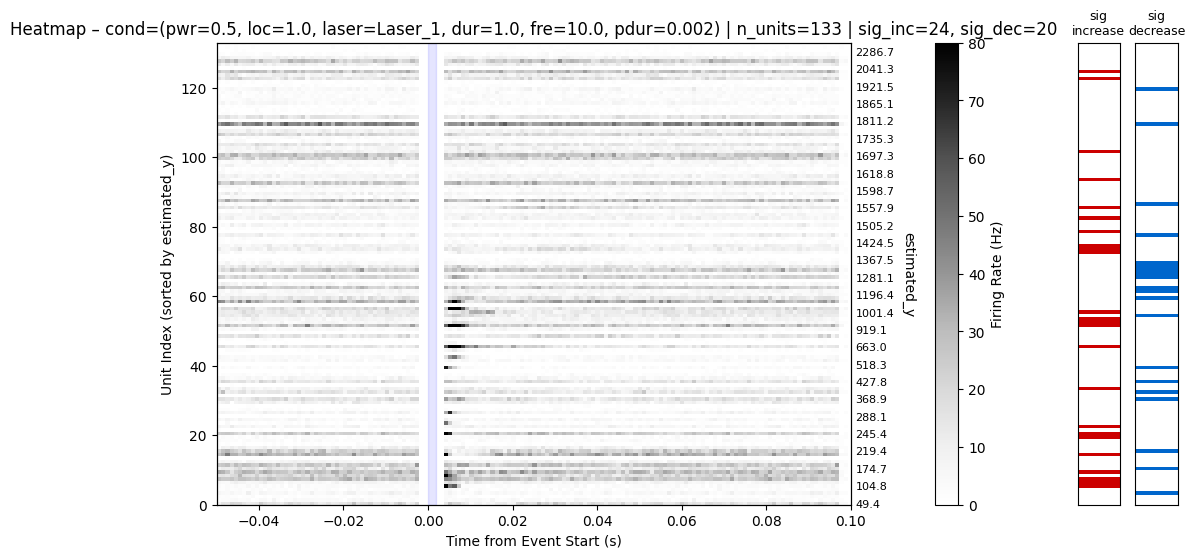

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


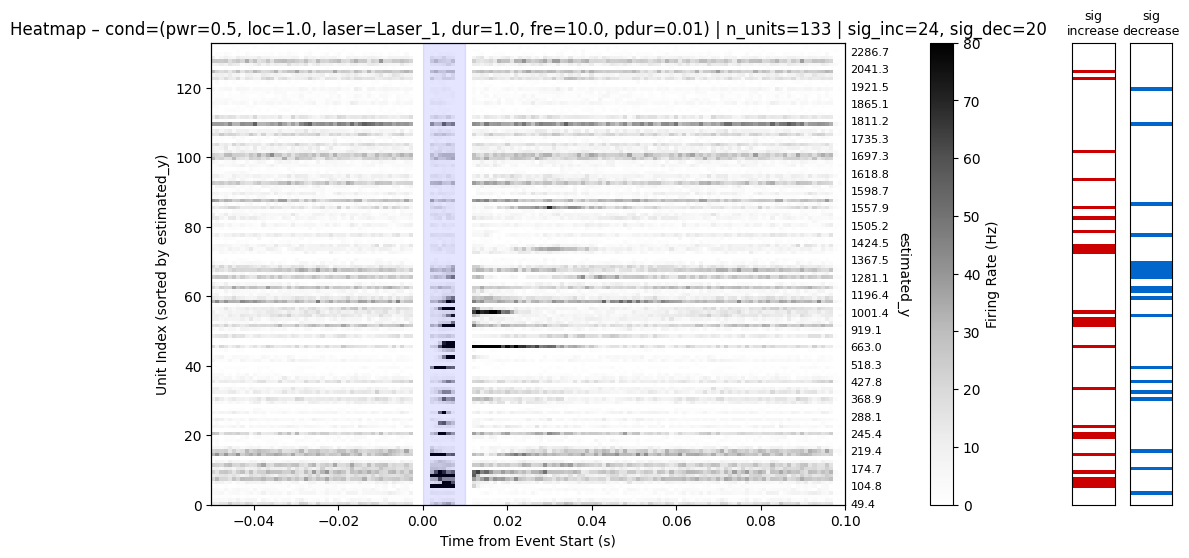

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


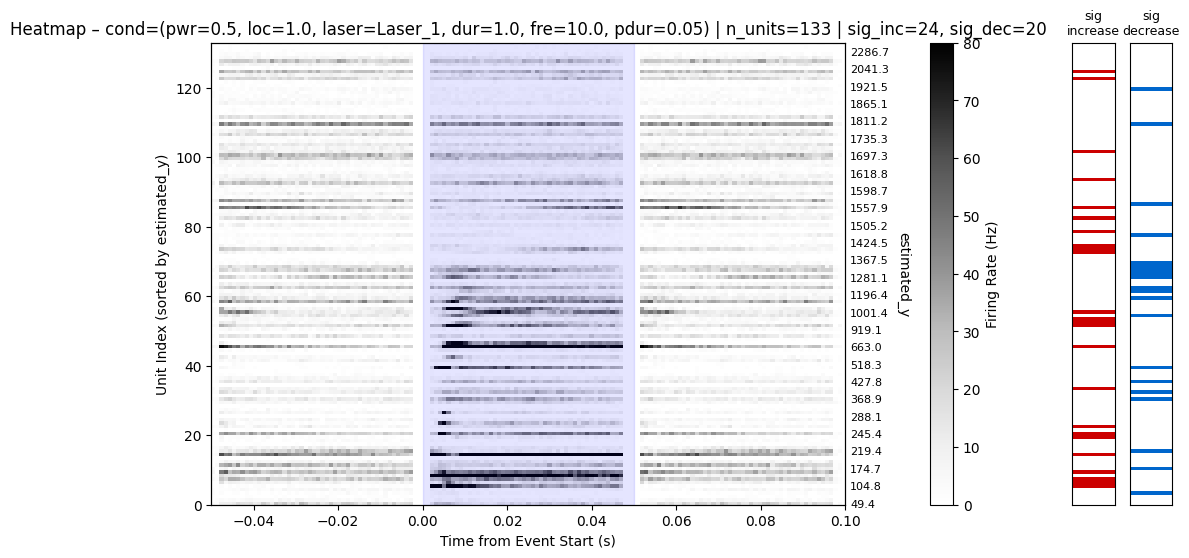

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


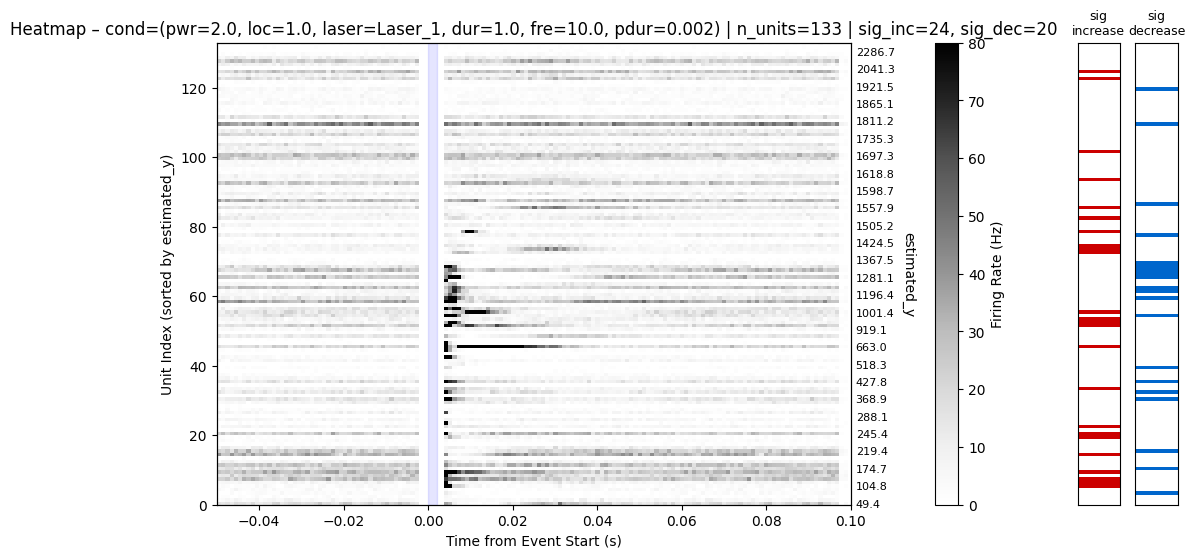

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


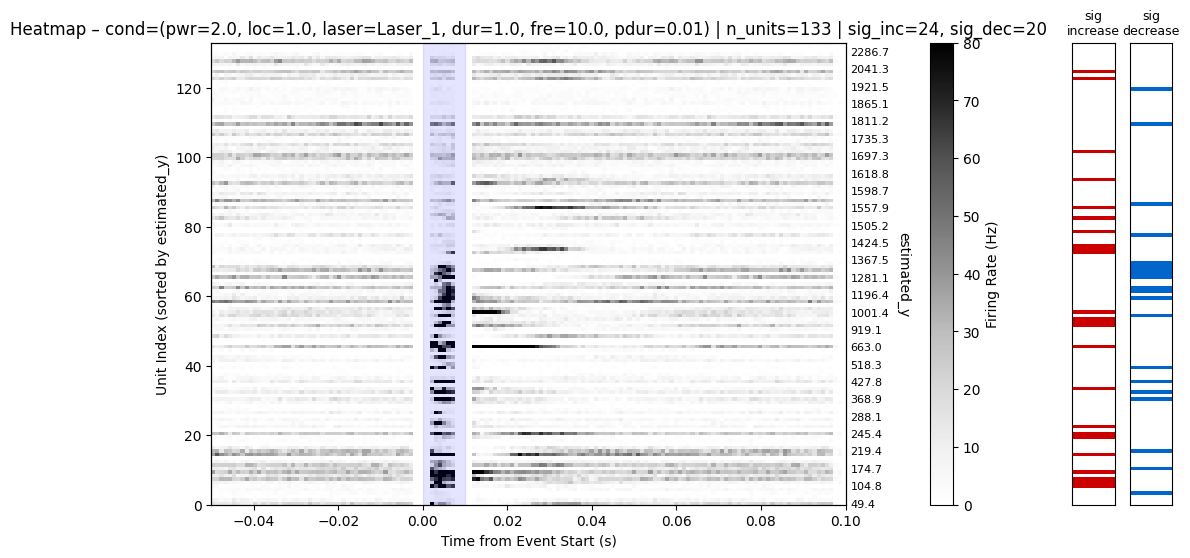

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


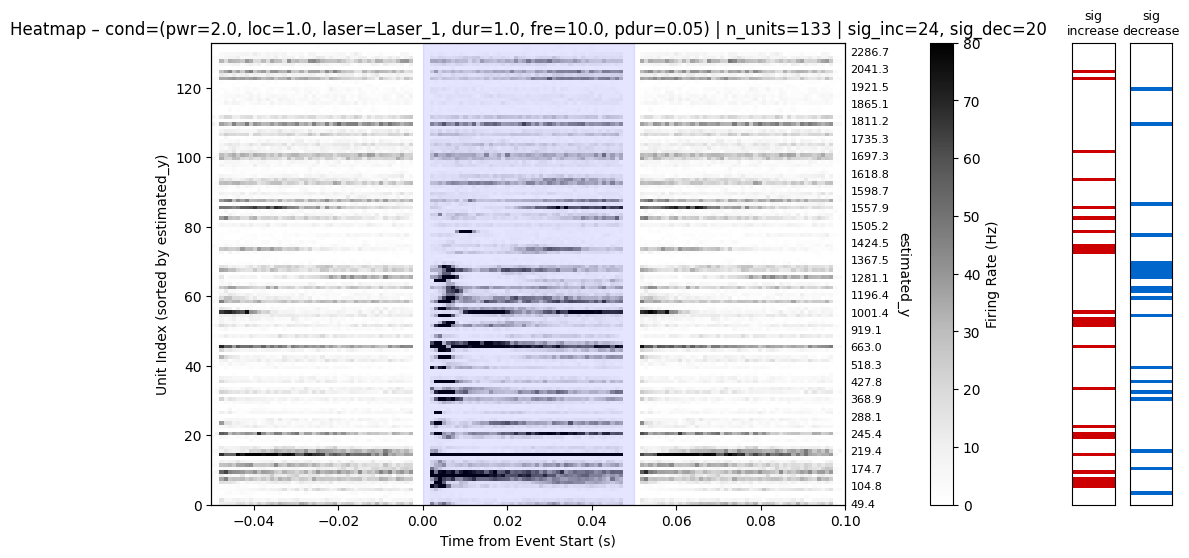

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


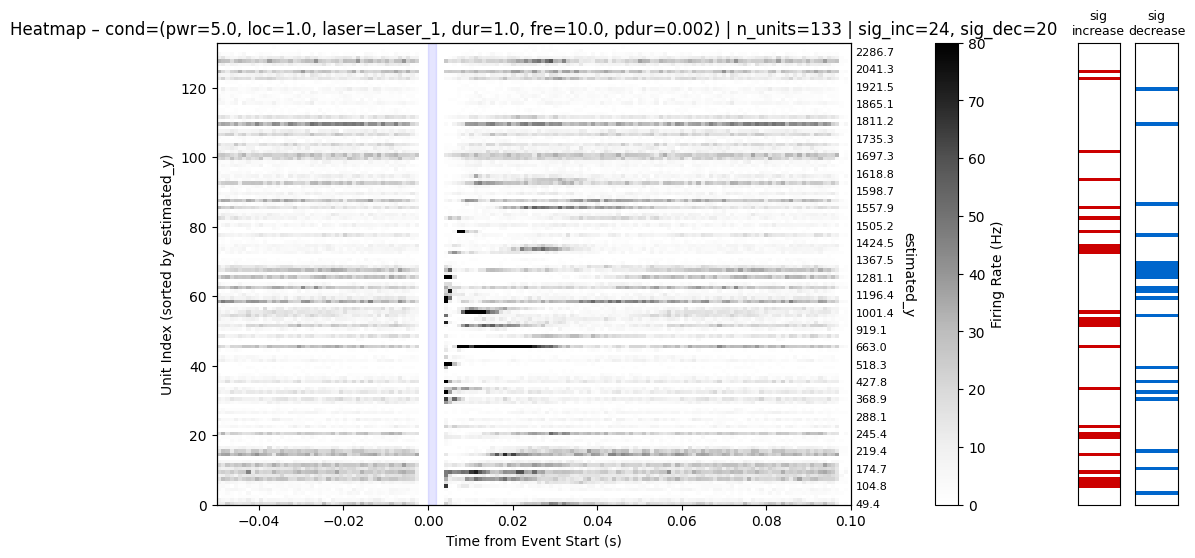

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


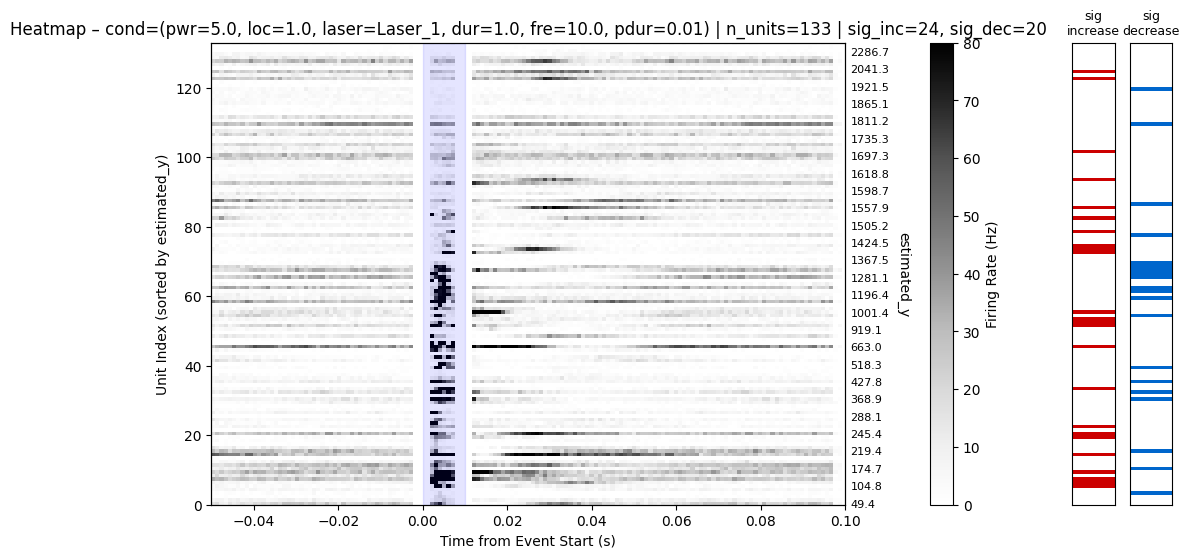

/root/capsule/src/aind_dft_ephys_analysis/optical_tagging.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


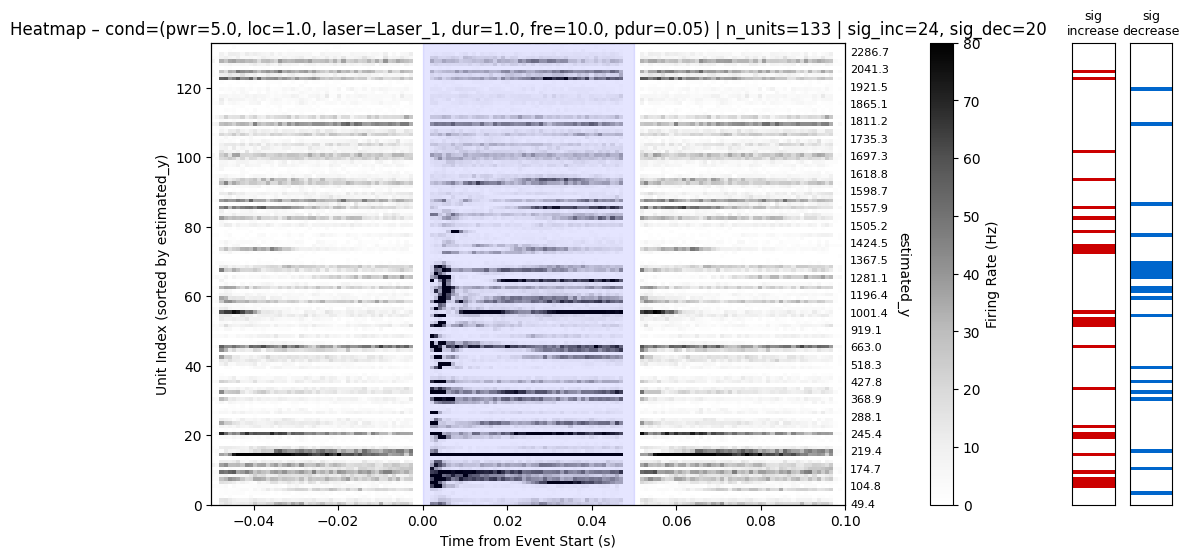

In [18]:
OptoTag.plot_heatmap(unit_index=all_units,df_summary = df_summary,sort_by='estimated_y',bin_size=0.001,time_window=[-0.05,0.1],save_path='/root/capsule/results/heatmap/',show_p_value_line=False)

In [19]:
len(all_units)

133

In [20]:
idx_max = (sigrows["stim_FR_mean"] - sigrows["baseline_FR_mean"]).idxmax()
row_max = sigrows.loc[idx_max]

In [ ]:
row_max

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


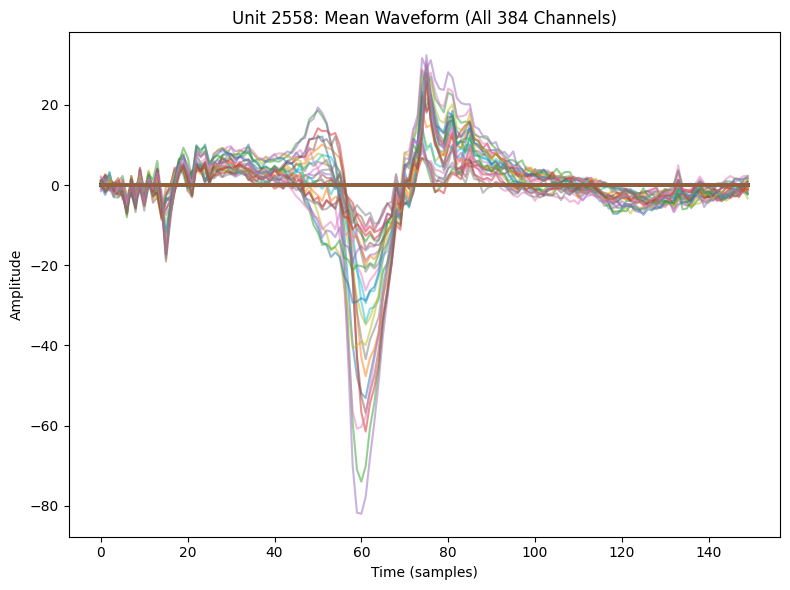

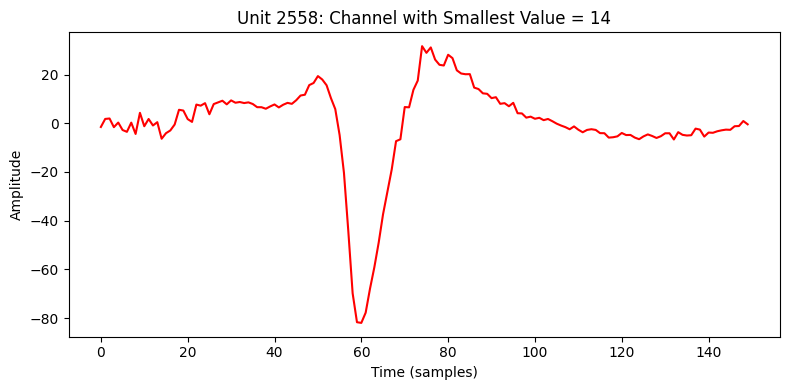

In [24]:
OptoTag.plot_waveform_mean(unit_id=2587,save_formats=["eps"])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


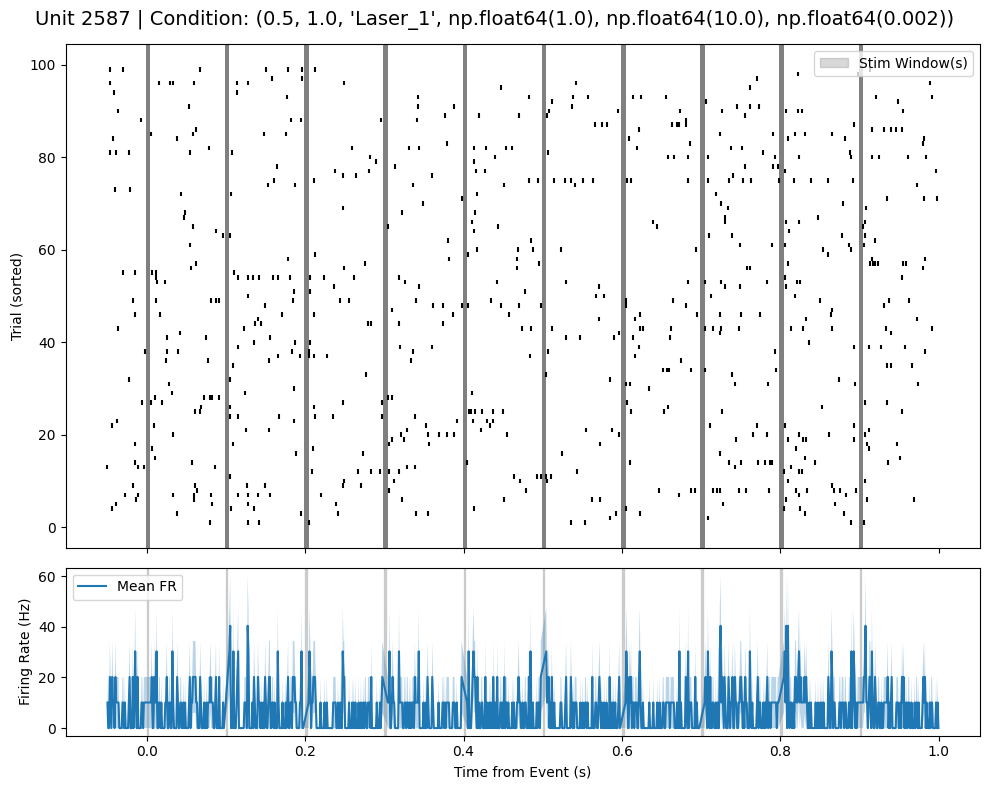

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


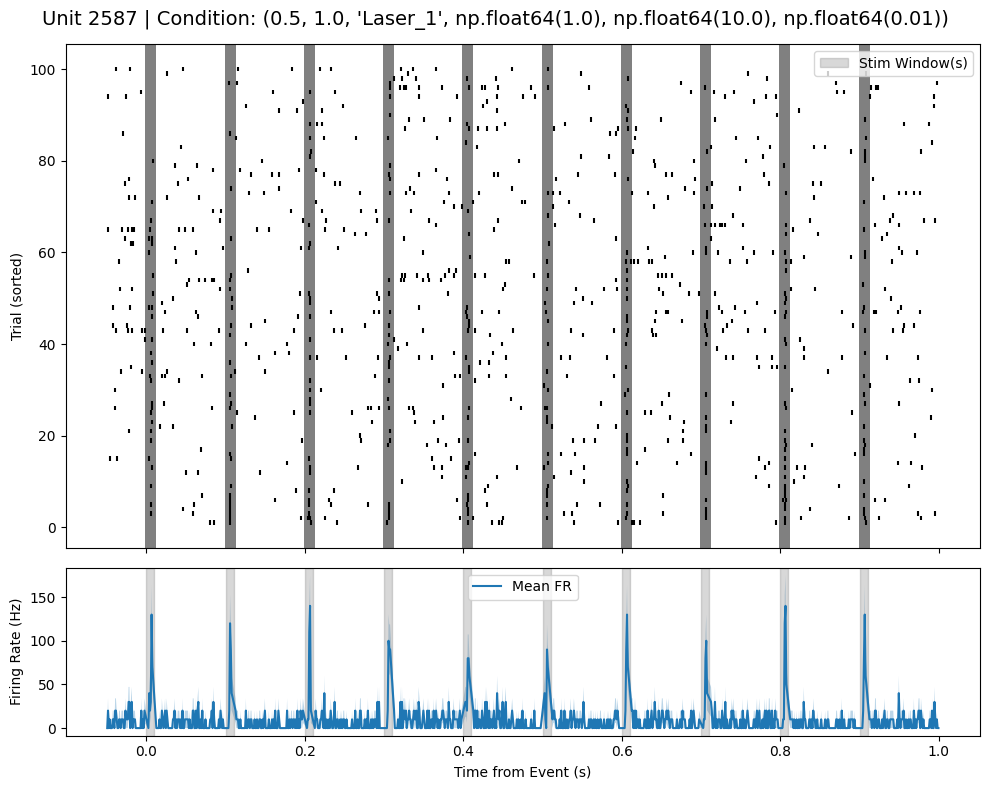

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


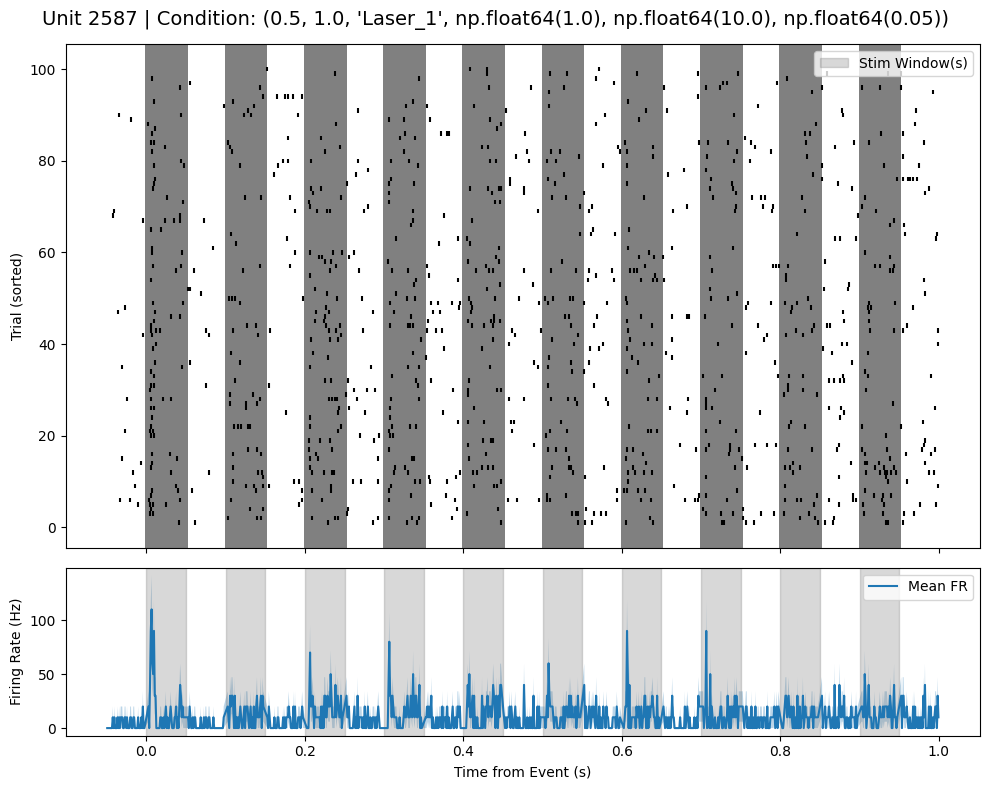

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


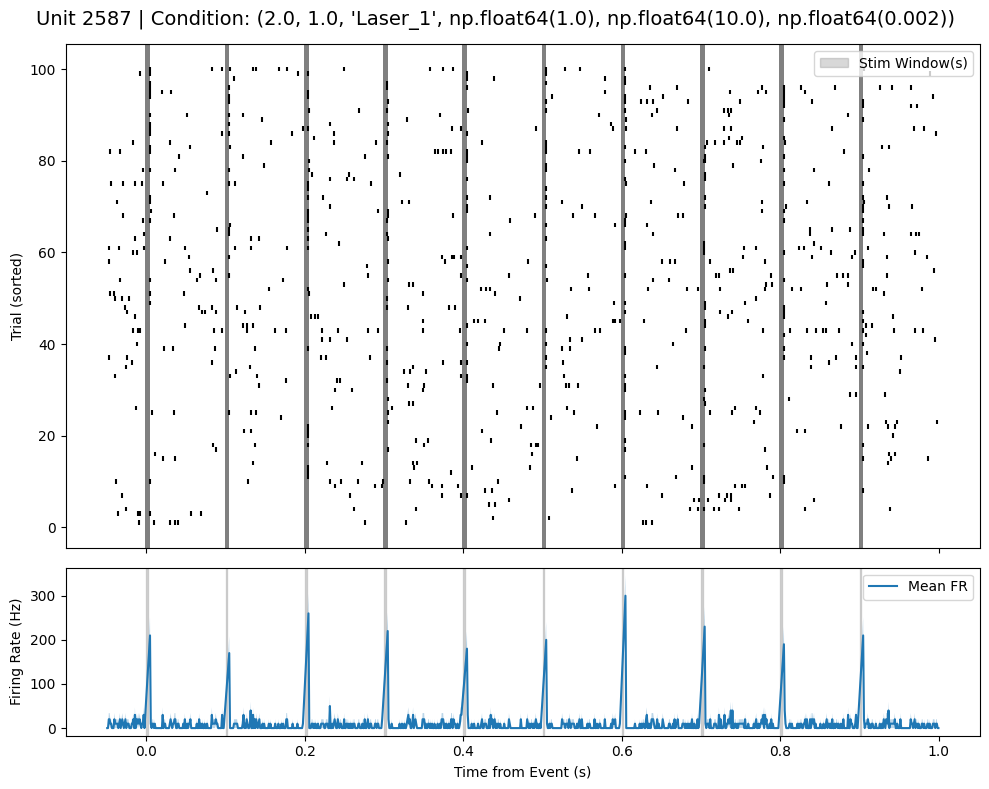

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


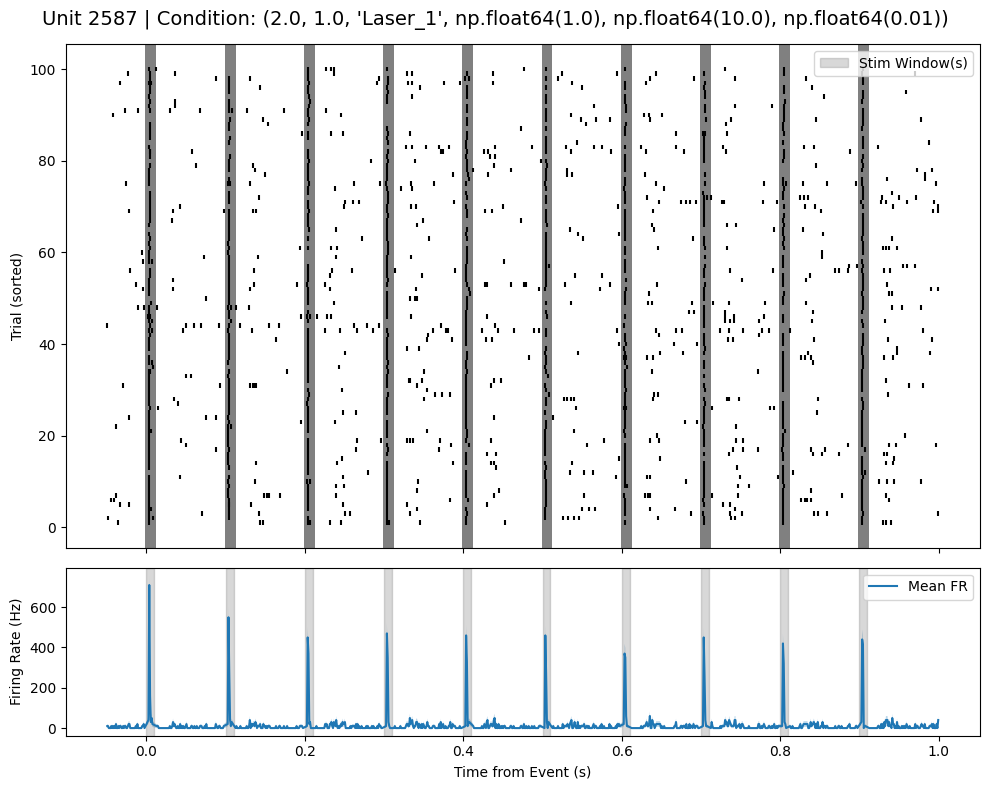

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


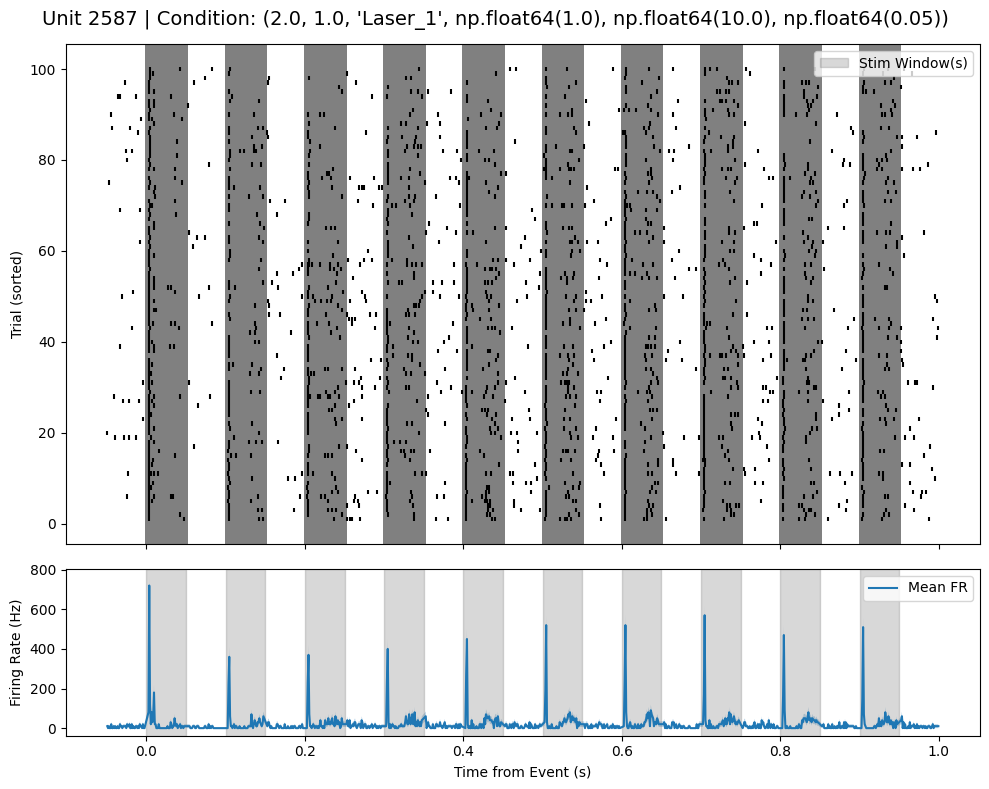

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


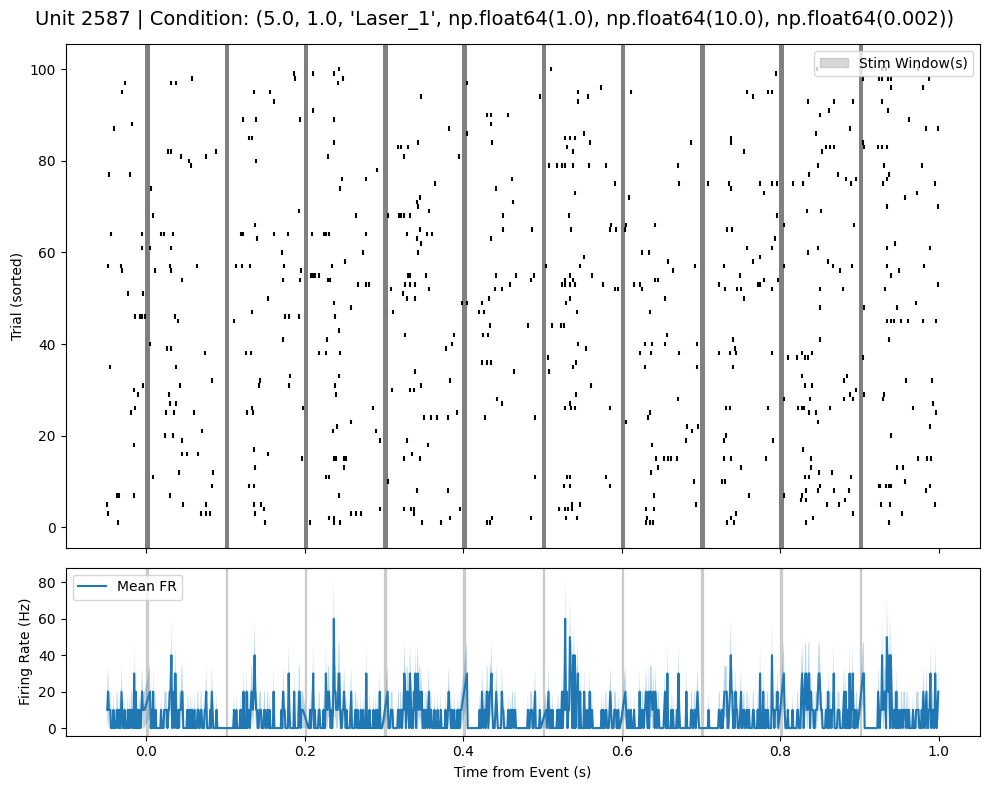

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


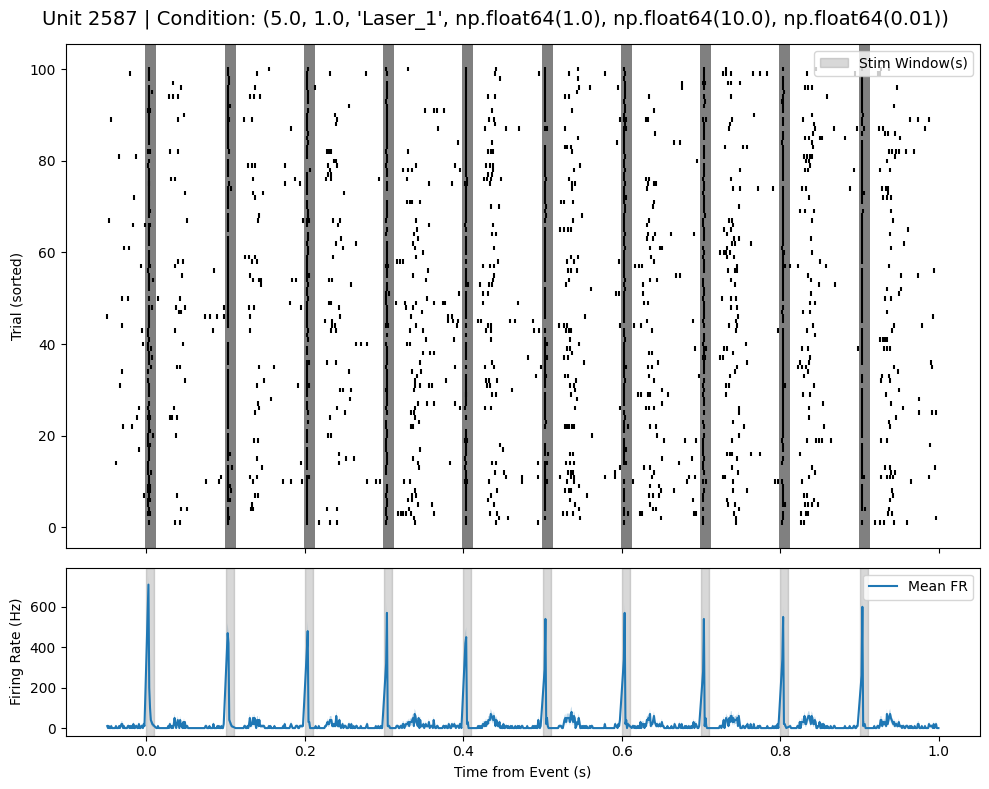

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


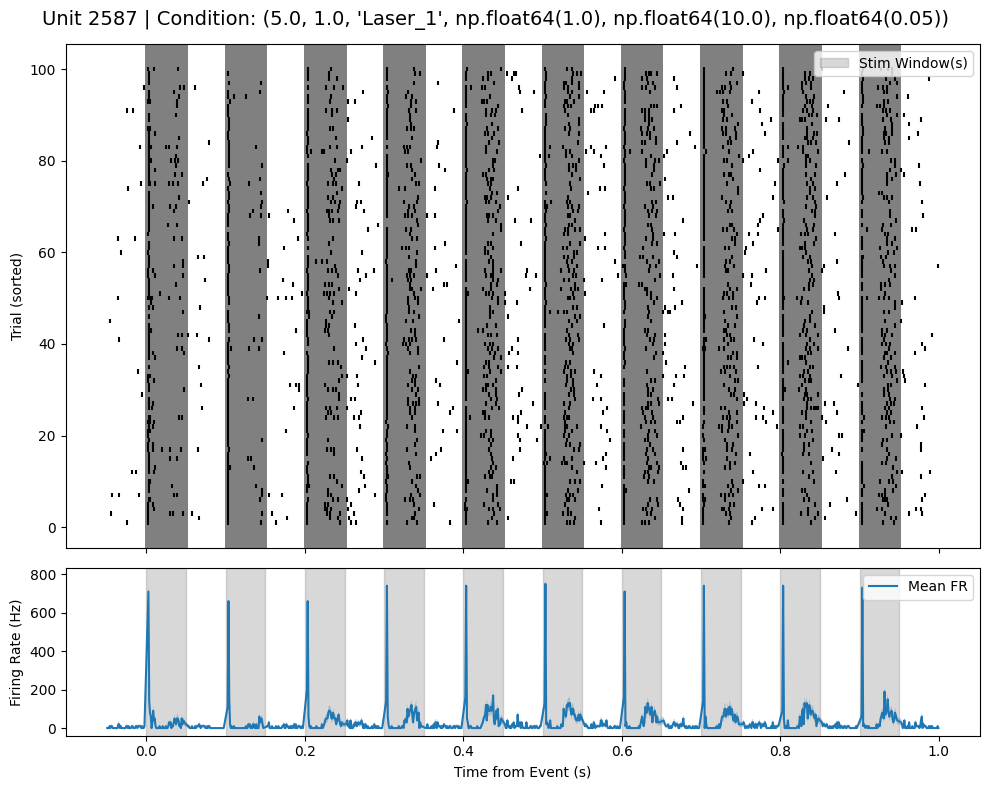

In [25]:
OptoTag.plot_raster_graph(unit_index=2587,bin_size=0.001,time_window=[-0.05, 1],align_to_event="laser",min_onset_time=5,save_formats= ["eps"])

In [ ]:
for u in common_units:
    OptoTag.plot_raster_graph(unit_index=u,bin_size=0.002,align_to_event="pulse")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


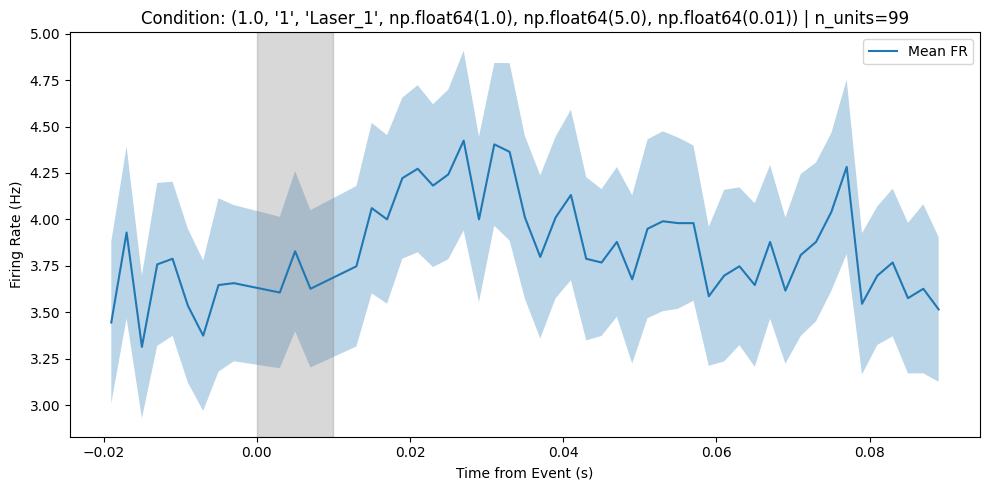

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


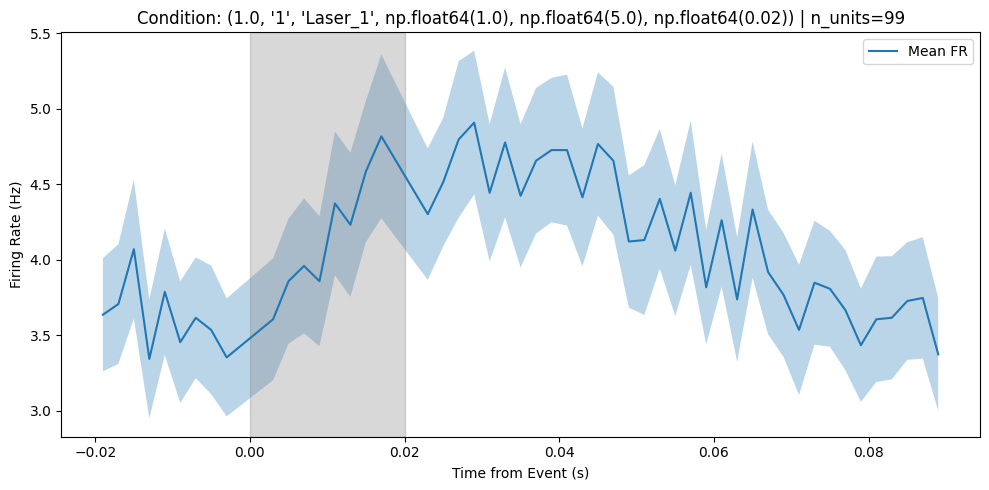

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


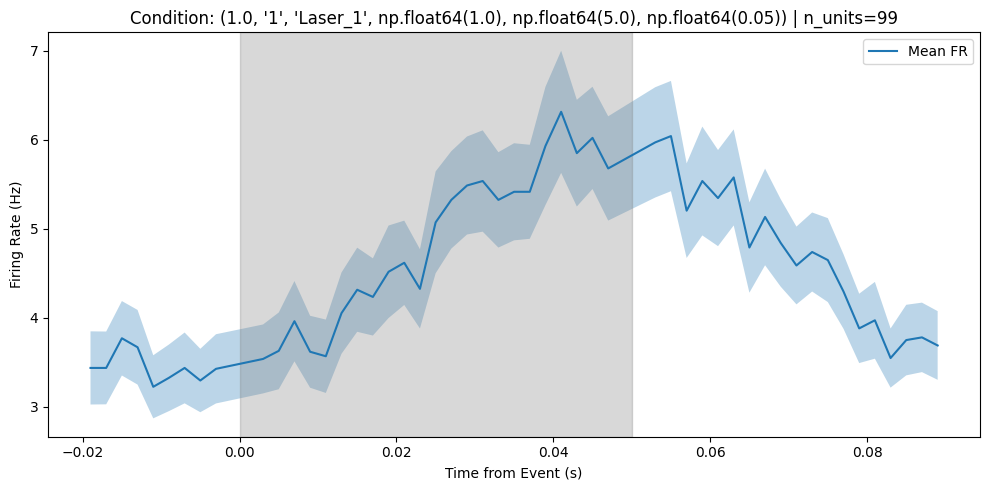

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


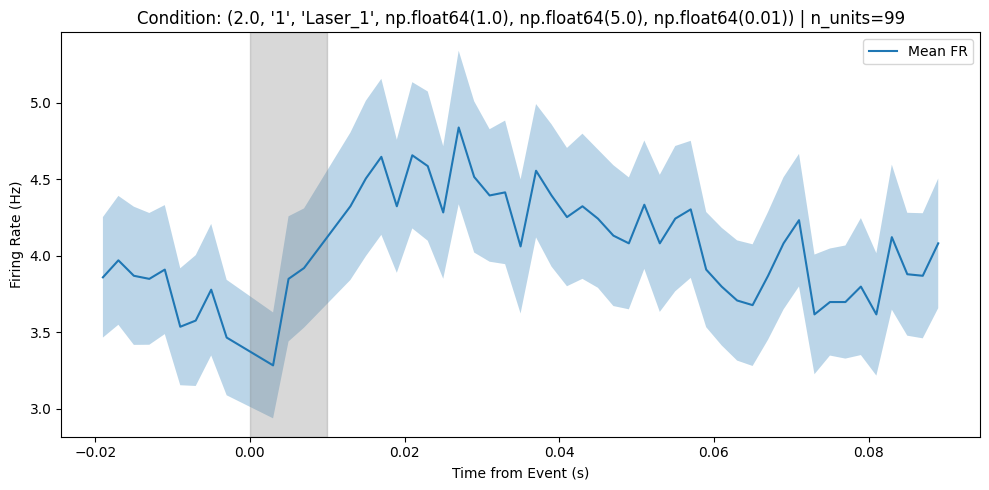

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


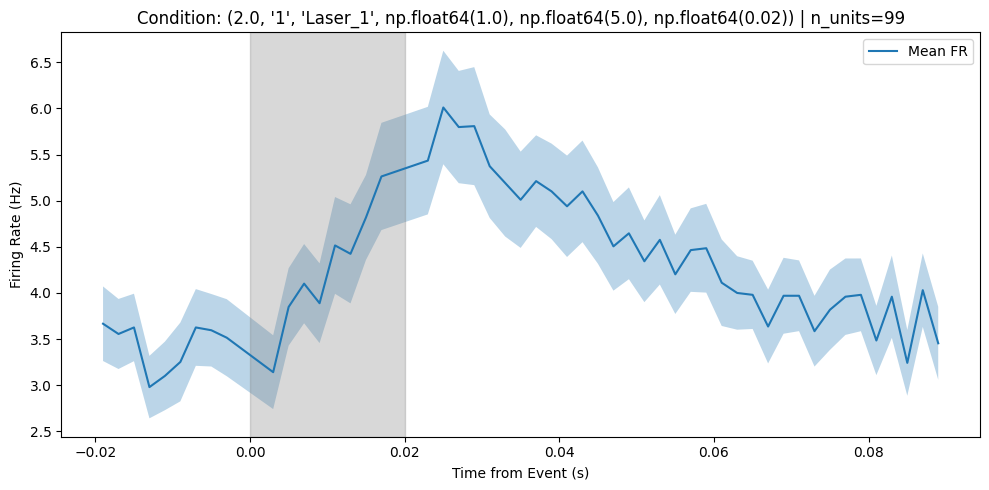

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


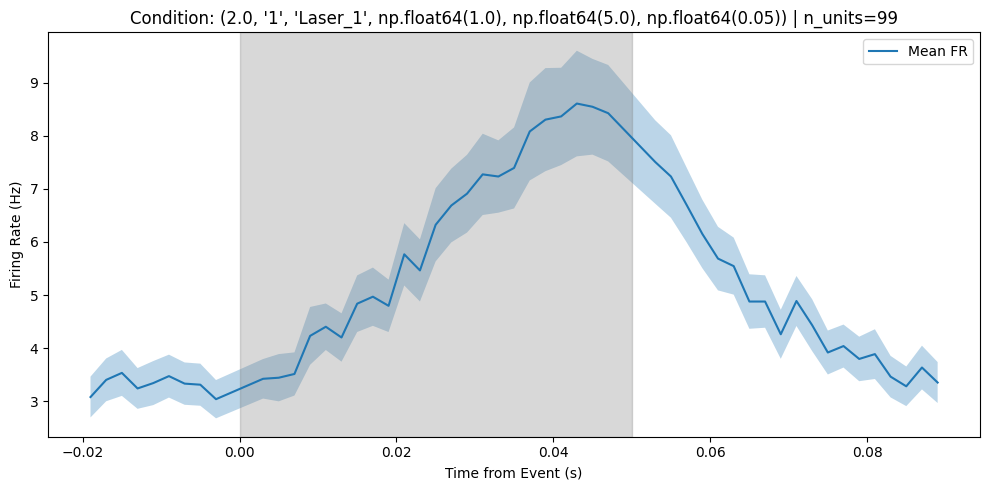

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


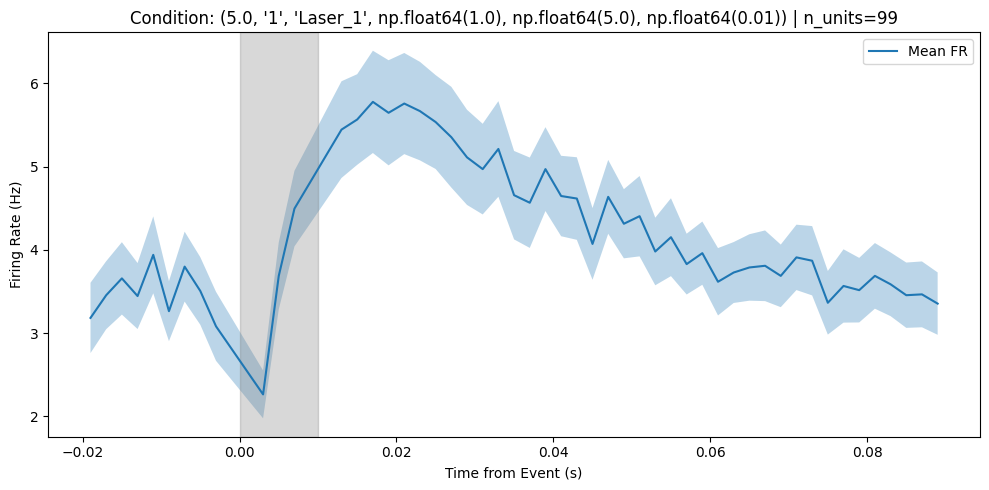

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


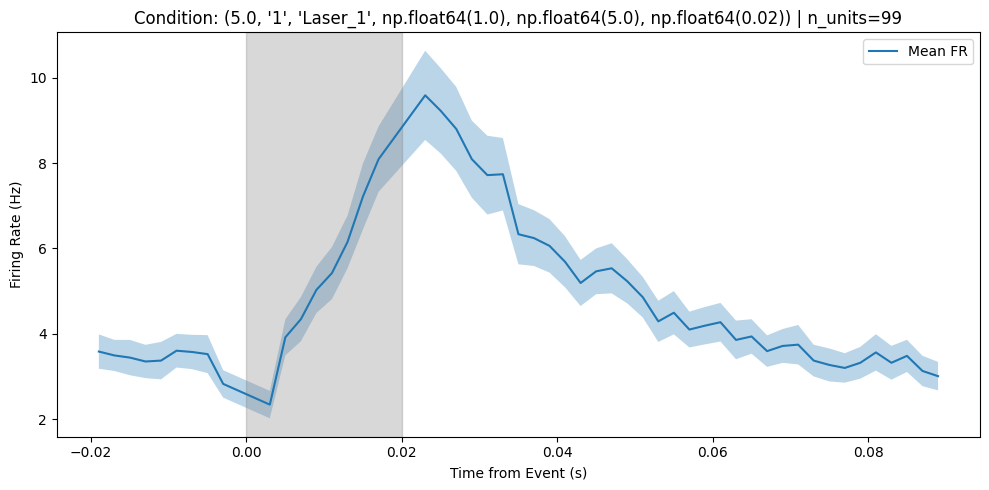

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


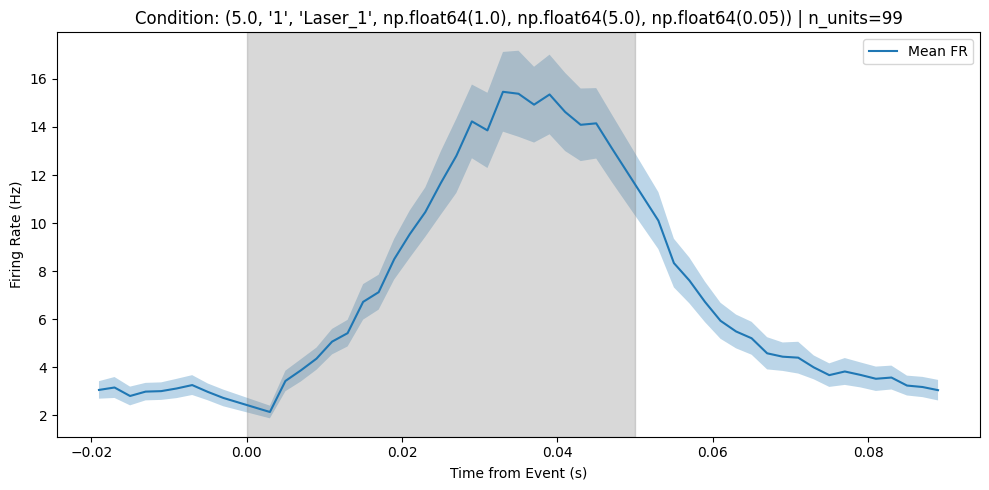

In [19]:
OptoTag.plot_psth(unit_index=common_units,bin_size=0.002,time_window=[-0.02, 0.09],removal_window=0.002,align_to_event='pulse',remove_artefacts=True)

/root/capsule/code/Class.py:1056: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(0, pdur, color=_lighten("gray", amount=0.6), edgecolor="none", zorder=0)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


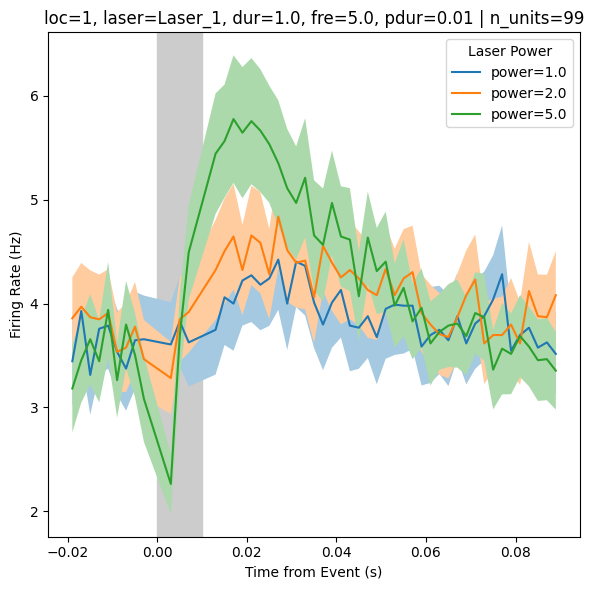

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


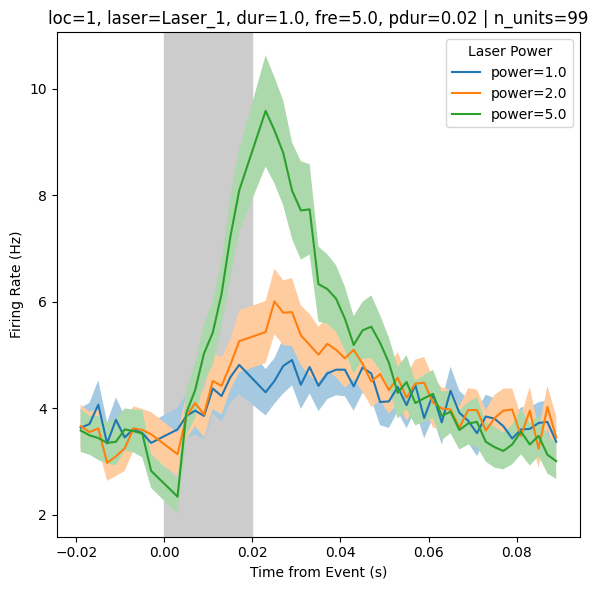

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


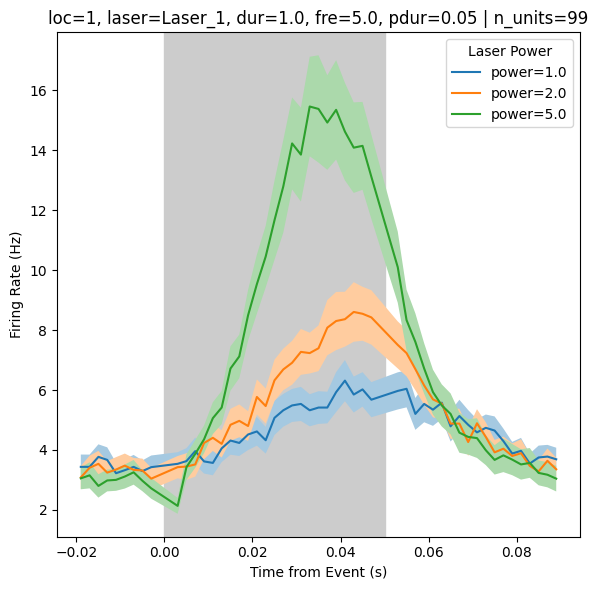

In [6]:
OptoTag.plot_psth_multiple_laser_power(unit_index=common_units,bin_size=0.002,time_window=[-0.02, 0.09],removal_window=0.002,align_to_event='pulse',remove_artefacts=True)

In [ ]:
len(all_units)

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


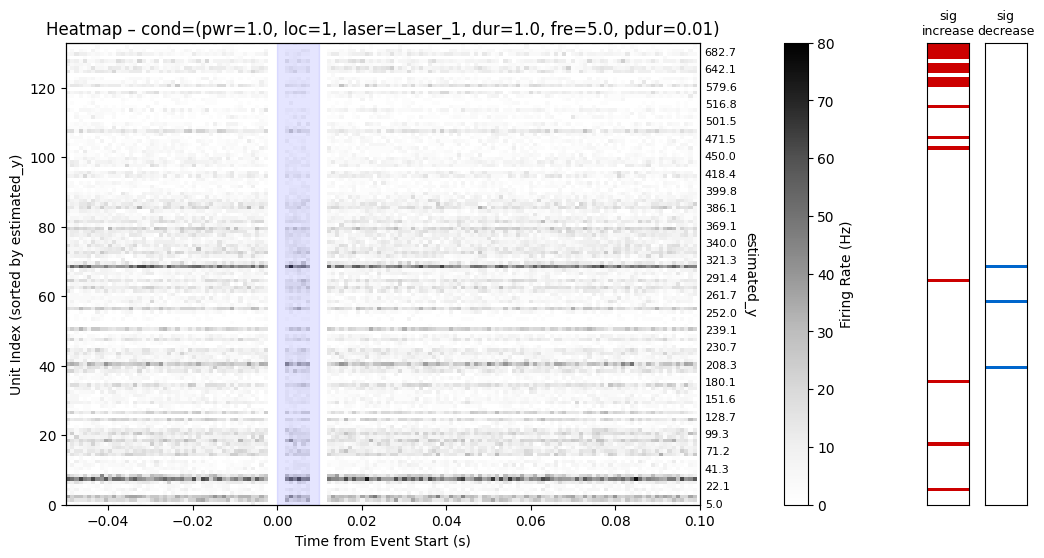

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


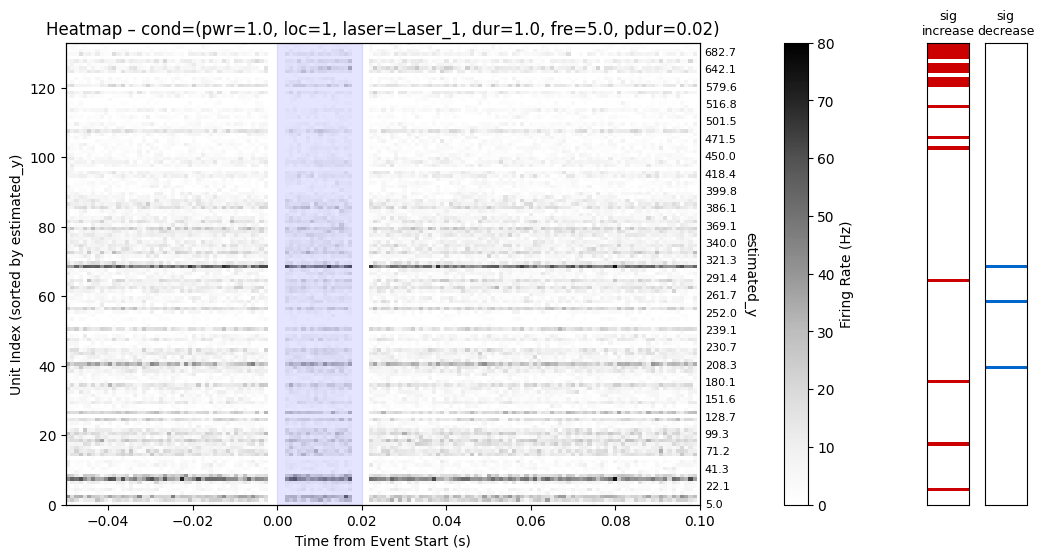

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


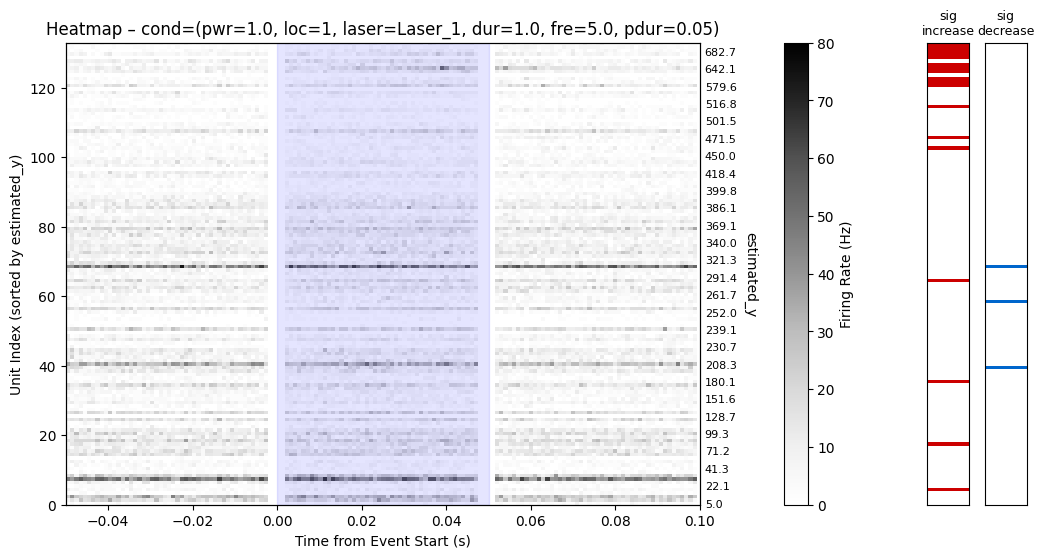

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


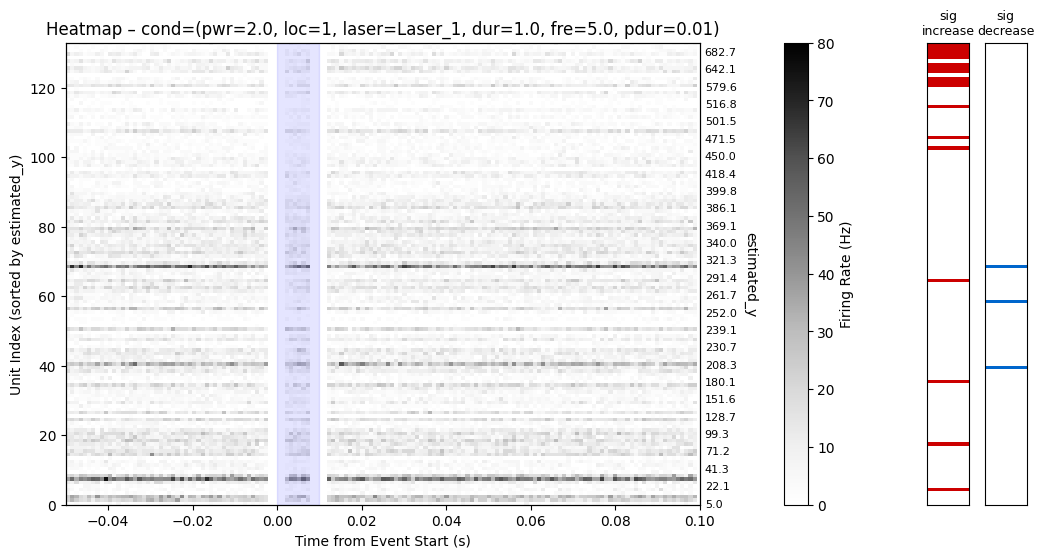

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


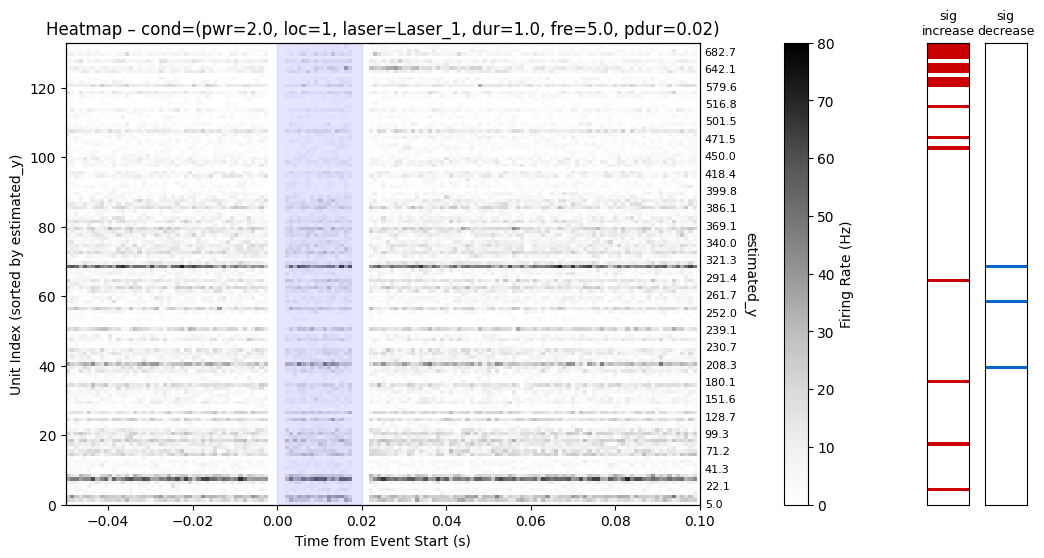

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


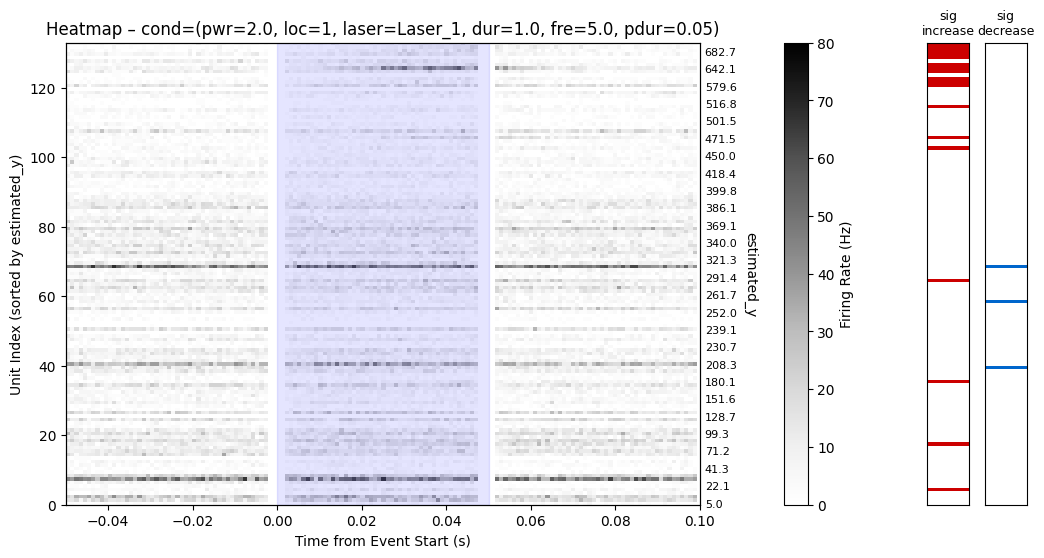

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


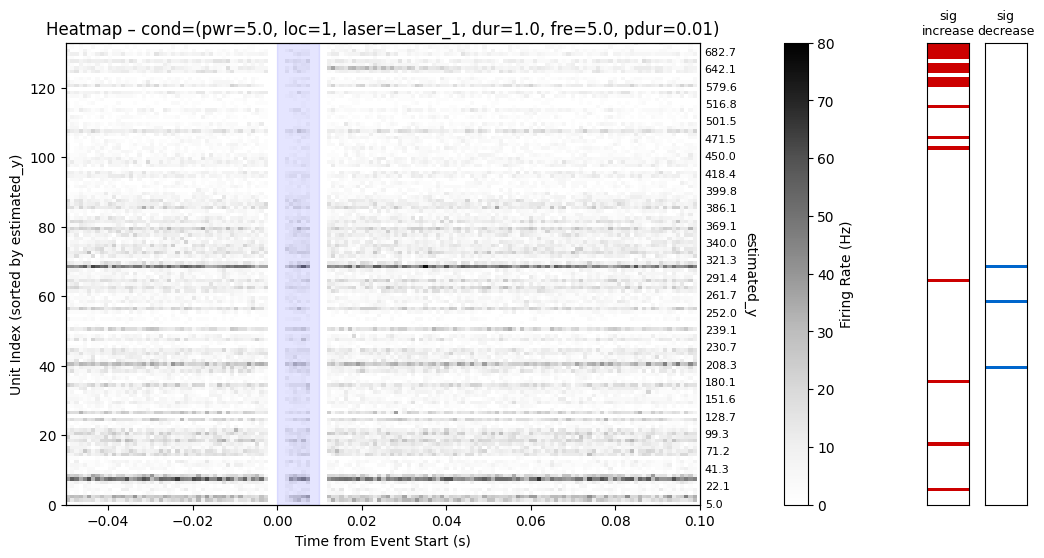

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


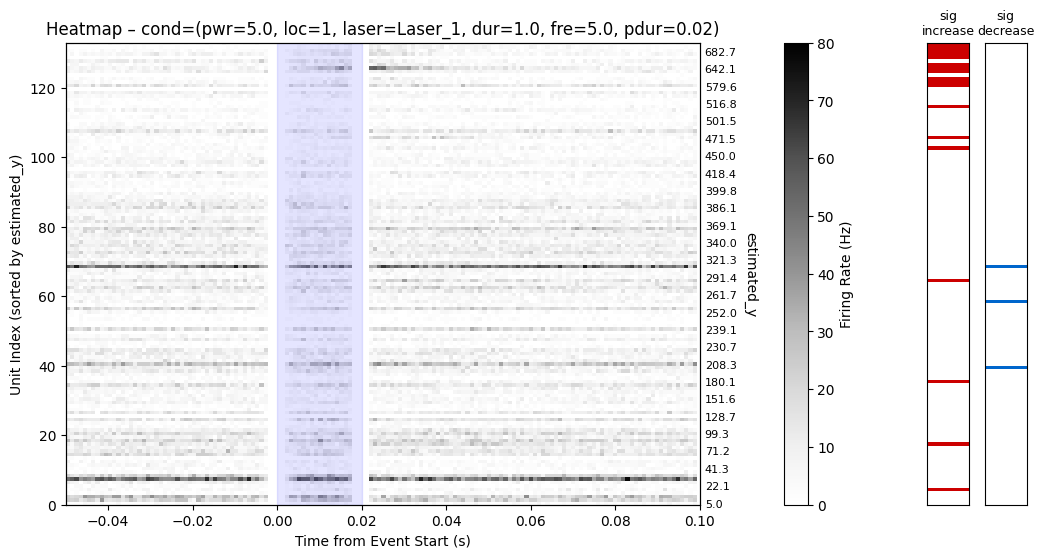

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


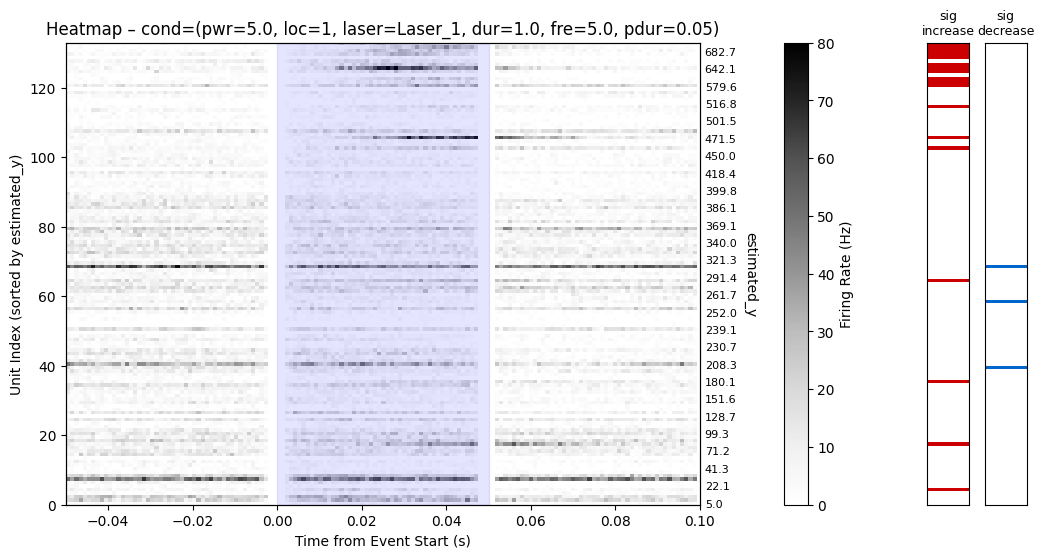

In [7]:
OptoTag.plot_heatmap(unit_index=all_units,df_summary = df_summary,sort_by='estimated_y',bin_size=0.001,time_window=[-0.05,0.1],save_path='/root/capsule/results/heatmap/',show_p_value_line=False)

In [ ]:
OptoTag.plot_psth_align_to_pulse(unit_index=common_units,bin_size=0.005,time_window=[-0.05,0.09],save_path='/root/capsule/results/',y_lim=[0,100])